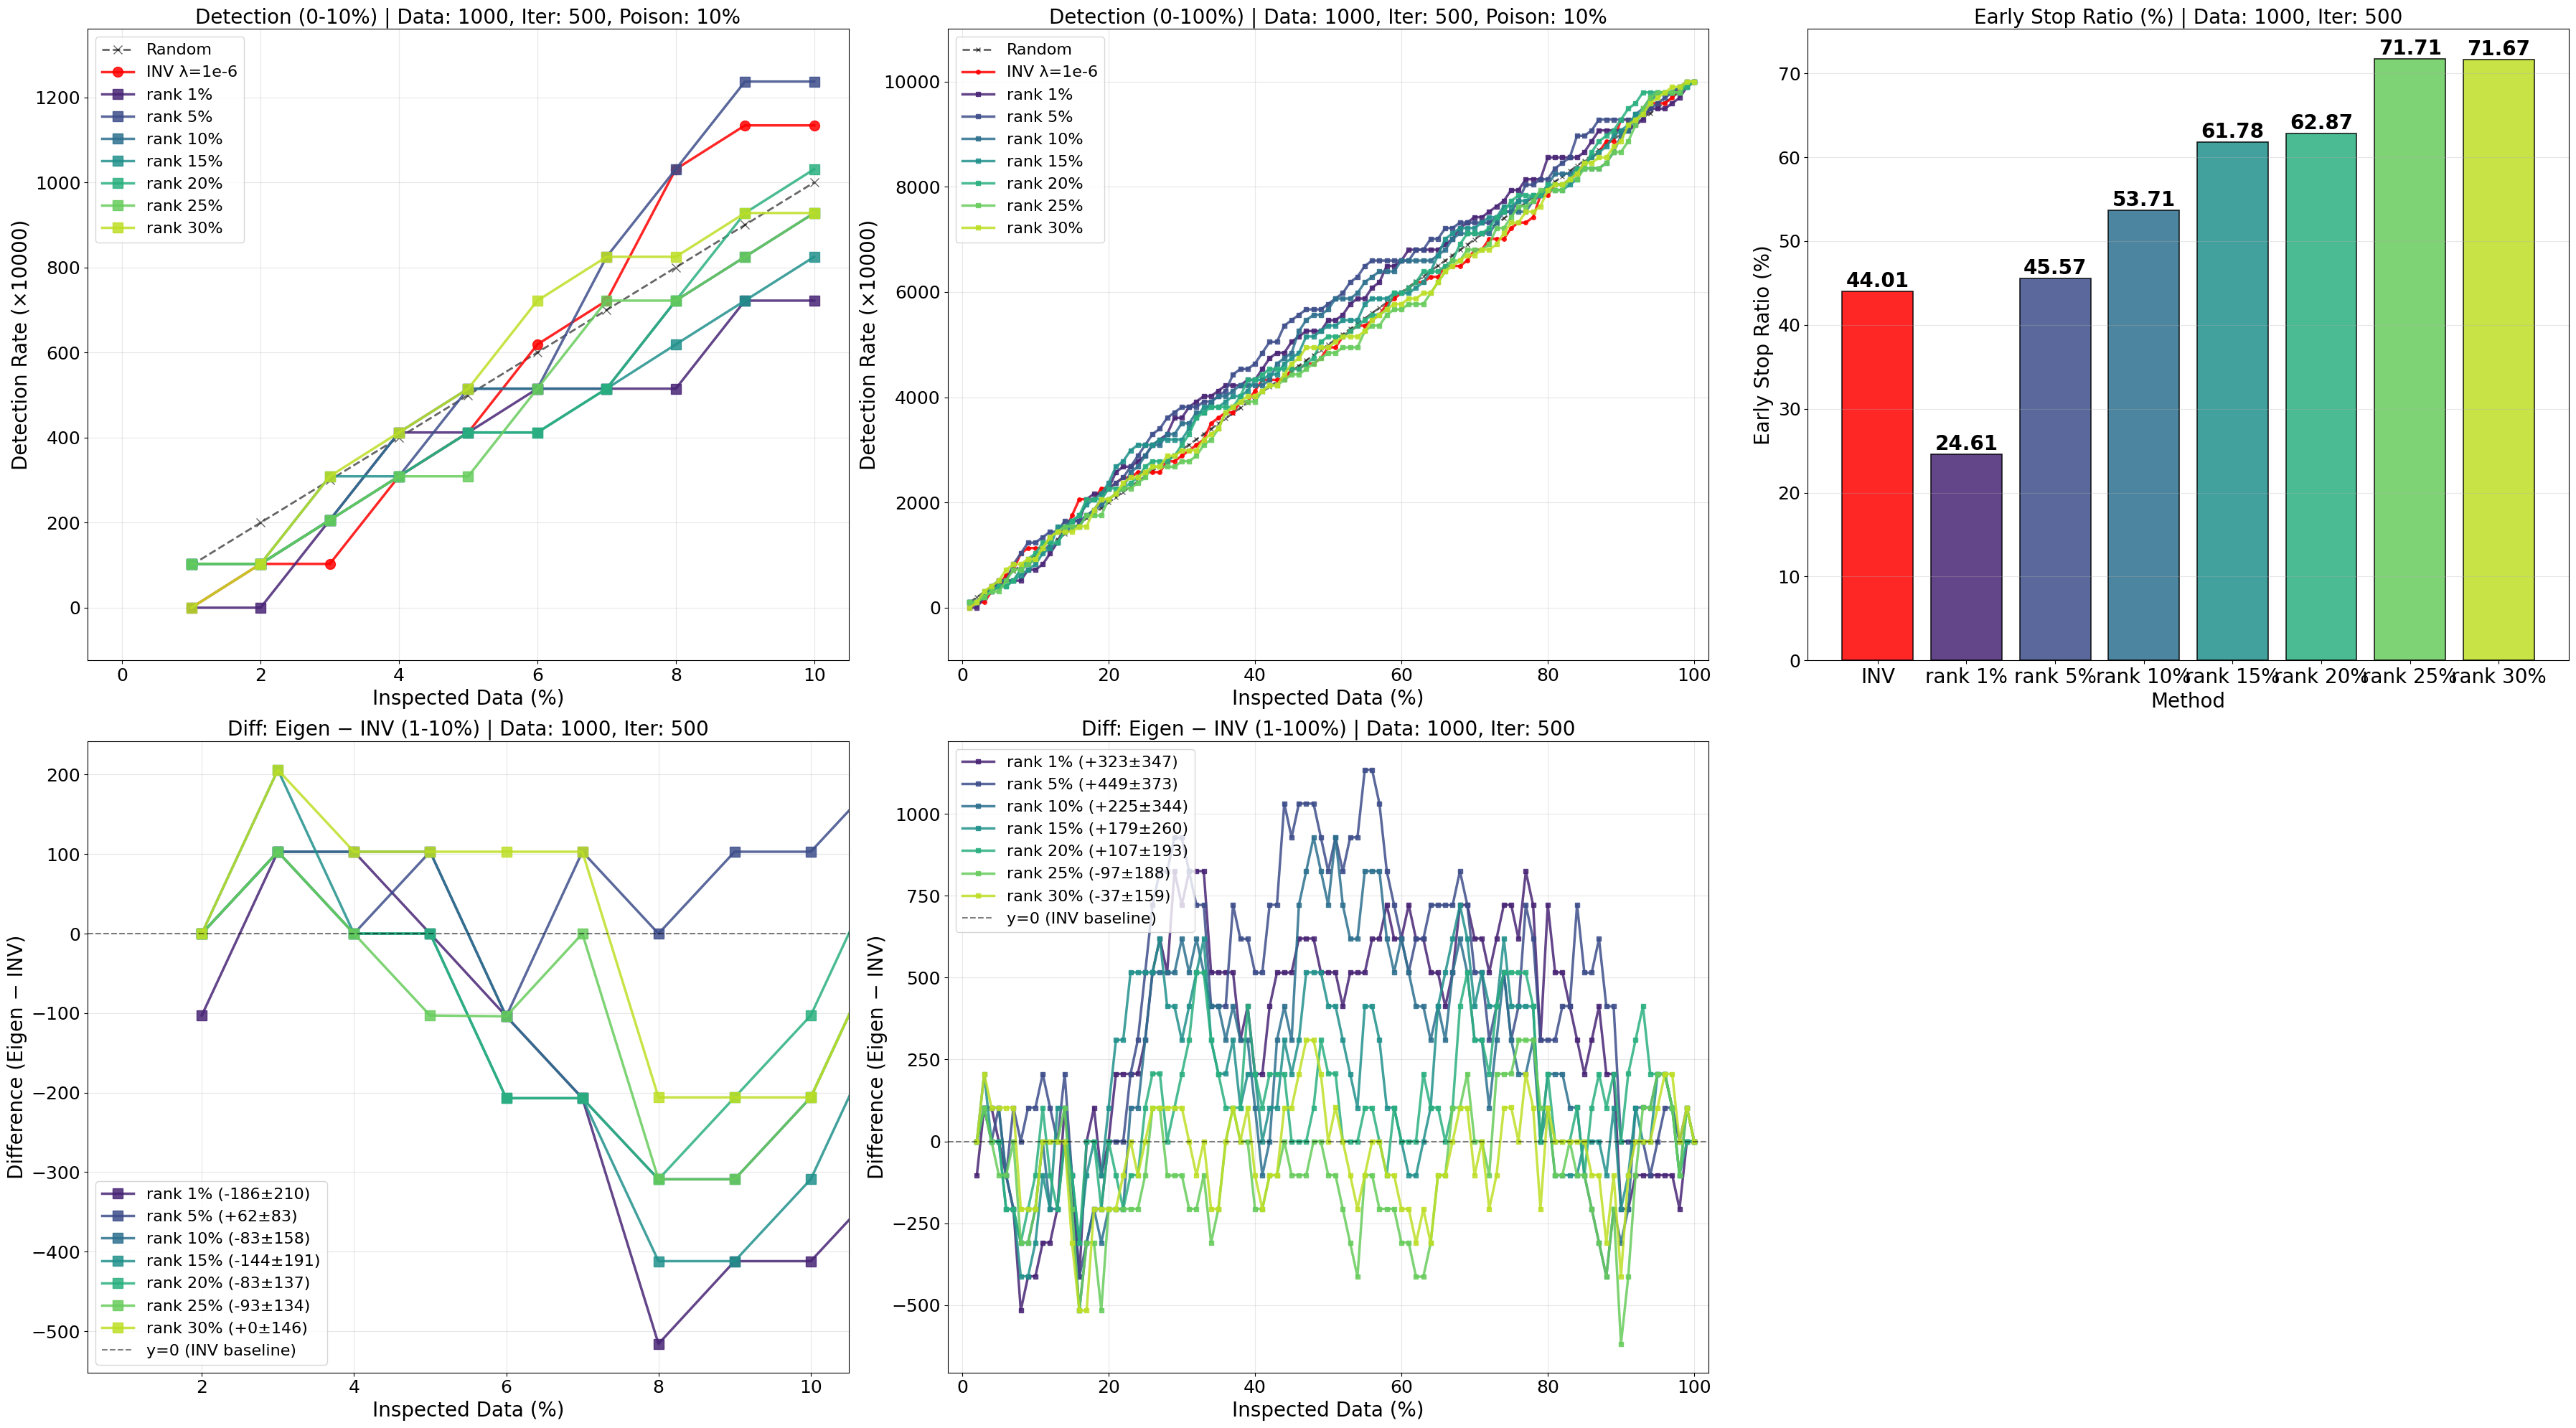

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 1000
iteration = 500
poison_pct = 10
# =========================

inspect_pct = [i for i in range(1, 101)]

# Detection rates (x10000, lowest Shapley first)
# INV baseline
inv_lam1e_6       = [0, 103, 103, 309, 412, 619, 722, 1031, 1134, 1134, 1134, 1340, 1443, 1443, 1753, 2062, 2062, 2062, 2268, 2268, 2371, 2474, 2474, 2577, 2577, 2577, 2577, 2784, 2784, 2887, 2990, 3093, 3196, 3505, 3608, 3711, 3711, 3918, 3918, 4124, 4330, 4330, 4330, 4330, 4536, 4536, 4639, 4639, 4742, 4948, 4948, 5155, 5258, 5361, 5361, 5464, 5567, 5773, 5876, 5979, 6082, 6186, 6186, 6289, 6289, 6495, 6495, 6495, 6598, 6804, 6804, 7010, 7010, 7010, 7216, 7320, 7320, 7423, 7835, 7835, 8041, 8041, 8144, 8247, 8454, 8557, 8660, 8866, 8866, 9278, 9278, 9278, 9381, 9588, 9588, 9588, 9691, 9897, 9897, 10000]
# Eigen Shapley detection rates
r1_eigen_lam1e_2  = [0, 0, 206, 412, 412, 515, 515, 515, 722, 722, 825, 1031, 1237, 1546, 1649, 1649, 2062, 2165, 2165, 2268, 2577, 2680, 2680, 2784, 2887, 3093, 3196, 3299, 3608, 3608, 3814, 3918, 4021, 4021, 4124, 4227, 4227, 4227, 4330, 4330, 4536, 4742, 4845, 4845, 5052, 5155, 5258, 5258, 5258, 5464, 5464, 5567, 5773, 5876, 5876, 6082, 6186, 6495, 6495, 6598, 6804, 6804, 6804, 6804, 6804, 6907, 7010, 7216, 7320, 7423, 7423, 7526, 7629, 7732, 7938, 7938, 8144, 8144, 8144, 8557, 8557, 8557, 8557, 8557, 8660, 8866, 9072, 9072, 9072, 9072, 9072, 9175, 9278, 9485, 9485, 9485, 9588, 9691, 9897, 10000]
r5_eigen_lam1e_2  = [103, 103, 206, 309, 515, 515, 825, 1031, 1237, 1237, 1340, 1443, 1443, 1649, 1649, 1649, 1753, 1856, 2062, 2268, 2371, 2474, 2680, 2887, 3093, 3299, 3402, 3608, 3711, 3814, 3814, 3814, 3918, 3918, 4021, 4124, 4433, 4536, 4536, 4639, 4845, 5052, 5052, 5361, 5464, 5567, 5670, 5670, 5670, 5773, 5876, 5979, 6186, 6289, 6495, 6598, 6598, 6598, 6598, 6598, 6598, 6804, 6804, 7010, 7010, 7216, 7216, 7320, 7320, 7320, 7320, 7320, 7423, 7526, 7526, 7732, 8041, 8041, 8144, 8144, 8351, 8454, 8557, 8969, 8969, 9072, 9278, 9278, 9278, 9278, 9278, 9278, 9381, 9485, 9588, 9691, 9794, 9897, 10000, 10000]
r10_eigen_lam1e_2 = [103, 103, 206, 412, 515, 515, 515, 722, 825, 928, 1134, 1134, 1237, 1443, 1546, 1546, 1753, 1856, 1959, 2062, 2165, 2268, 2577, 2680, 2887, 3093, 3093, 3299, 3299, 3505, 3505, 3711, 3711, 3918, 4021, 4021, 4124, 4227, 4227, 4227, 4227, 4330, 4639, 4742, 4845, 5258, 5464, 5567, 5567, 5670, 5876, 5876, 5876, 5979, 6186, 6289, 6392, 6392, 6392, 6598, 6598, 6598, 6598, 6598, 6701, 6804, 7010, 7113, 7113, 7113, 7113, 7113, 7320, 7526, 7526, 7526, 7526, 7732, 7835, 8041, 8247, 8247, 8247, 8351, 8351, 8351, 8351, 8454, 8660, 8969, 9072, 9381, 9485, 9691, 9794, 9794, 9794, 9897, 9897, 10000]
r15_eigen_lam1e_2 = [103, 103, 309, 309, 412, 412, 515, 619, 722, 825, 1031, 1134, 1546, 1546, 1649, 1753, 1959, 2062, 2165, 2371, 2680, 2784, 2990, 3093, 3093, 3093, 3196, 3196, 3196, 3196, 3402, 3608, 3814, 3814, 3814, 3918, 4021, 4021, 4124, 4330, 4330, 4433, 4433, 4639, 4742, 4845, 5155, 5155, 5258, 5361, 5361, 5464, 5464, 5464, 5773, 5876, 5876, 5876, 5979, 5979, 5979, 6082, 6186, 6392, 6701, 7010, 7113, 7216, 7216, 7216, 7320, 7423, 7423, 7629, 7629, 7732, 7732, 7835, 7835, 7938, 7938, 7938, 8041, 8144, 8454, 8557, 8660, 8763, 8969, 9072, 9175, 9381, 9381, 9588, 9794, 9794, 9794, 9794, 10000, 10000]
r20_eigen_lam1e_2 = [103, 103, 206, 309, 412, 412, 515, 722, 928, 1031, 1237, 1237, 1237, 1443, 1649, 1753, 2062, 2062, 2062, 2268, 2268, 2268, 2371, 2474, 2680, 2784, 2784, 2784, 2887, 3093, 3299, 3608, 3711, 3814, 3814, 3814, 3814, 4021, 4330, 4330, 4433, 4536, 4536, 4536, 4536, 4536, 4639, 4742, 5052, 5155, 5155, 5155, 5258, 5361, 5464, 5567, 5567, 5670, 5979, 5979, 6082, 6186, 6392, 6392, 6392, 6495, 6598, 6907, 7113, 7113, 7113, 7216, 7423, 7526, 7732, 7835, 7835, 7835, 7835, 8041, 8041, 8041, 8144, 8351, 8351, 8660, 8866, 8969, 9072, 9278, 9485, 9588, 9794, 9794, 9794, 9794, 9794, 9794, 9897, 10000]
r25_eigen_lam1e_2 = [103, 103, 206, 309, 309, 515, 722, 722, 825, 928, 1134, 1340, 1443, 1546, 1546, 1546, 1753, 1753, 1753, 2062, 2165, 2268, 2268, 2371, 2474, 2680, 2680, 2680, 2680, 2784, 2784, 2887, 3093, 3196, 3402, 3711, 3814, 3918, 3918, 3918, 4124, 4227, 4227, 4330, 4433, 4433, 4536, 4639, 4742, 4845, 4845, 4948, 4948, 4948, 5258, 5361, 5361, 5567, 5670, 5670, 5773, 5773, 5773, 5979, 6186, 6392, 6598, 6598, 6804, 6804, 6804, 6907, 7216, 7216, 7423, 7629, 7629, 7732, 7938, 7938, 7938, 7938, 8144, 8144, 8351, 8351, 8351, 8454, 8660, 8660, 8866, 9175, 9485, 9691, 9794, 9794, 9794, 9794, 10000, 10000]
r30_eigen_lam1e_2 = [0, 103, 309, 412, 515, 722, 825, 825, 928, 928, 1134, 1340, 1443, 1443, 1443, 1546, 1546, 1856, 2062, 2062, 2165, 2371, 2474, 2474, 2577, 2680, 2680, 2887, 2887, 2990, 2990, 2990, 3196, 3299, 3402, 3711, 3814, 3918, 4021, 4021, 4124, 4227, 4227, 4433, 4639, 4742, 4948, 4948, 4948, 4948, 5052, 5155, 5155, 5155, 5258, 5464, 5567, 5670, 5773, 5773, 5876, 5876, 5979, 5979, 6186, 6392, 6495, 6598, 6701, 6701, 6804, 6804, 6907, 7113, 7320, 7320, 7526, 7526, 7629, 7938, 8041, 8041, 8144, 8247, 8454, 8454, 8557, 8557, 8763, 8866, 9175, 9278, 9381, 9588, 9691, 9794, 9897, 9897, 10000, 10000]

# Early stop ratios (%)
inv_early_stop       = [44.01]
r1_eigen_early_stop  = [24.61]
r5_eigen_early_stop  = [45.57]
r10_eigen_early_stop = [53.71]
r15_eigen_early_stop = [61.78]
r20_eigen_early_stop = [62.87]
r25_eigen_early_stop = [71.71]
r30_eigen_early_stop = [71.67]

# Random baseline (theoretical): inspecting i% finds i% of poisoned
random_baseline = [i * 100 for i in range(1, 101)]

# Create figure with 6 subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(36, 20))
axes = axes.flatten()

# Prepare color schemes
inv_color = 'red'
random_color = 'black'
eigen_colors = plt.cm.viridis(np.linspace(0.1, 0.9, 7))

# Eigen data
eigen_data = [
    (r1_eigen_lam1e_2, 'rank 1%'),
    (r5_eigen_lam1e_2, 'rank 5%'),
    (r10_eigen_lam1e_2, 'rank 10%'),
    (r15_eigen_lam1e_2, 'rank 15%'),
    (r20_eigen_lam1e_2, 'rank 20%'),
    (r25_eigen_lam1e_2, 'rank 25%'),
    (r30_eigen_lam1e_2, 'rank 30%')
]

inspect_pct_10 = inspect_pct[:10]
inspect_pct_1_to_10 = inspect_pct[1:11]
inspect_pct_1_to_99 = inspect_pct[1:]

# ===== Subplot (1,1): Detection Rate 0-10% =====
ax1 = axes[0]

ax1.plot(inspect_pct_10, random_baseline[:10], color=random_color, linewidth=2.0,
         linestyle='--', marker='x', markersize=8, label='Random', alpha=0.6)
if inv_lam1e_6:
    ax1.plot(inspect_pct_10, inv_lam1e_6[:10], color=inv_color, linewidth=2.5,
             linestyle='-', marker='o', markersize=10, label='INV λ=1e-6', alpha=0.85)
for i, (data, label) in enumerate(eigen_data):
    if data:
        ax1.plot(inspect_pct_10, data[:10], color=eigen_colors[i], linewidth=2.5,
                 linestyle='-', marker='s', markersize=10, label=label, alpha=0.85)

all_data_10 = [random_baseline[:10]] + ([inv_lam1e_6[:10]] if inv_lam1e_6 else []) + [d[0][:10] for d in eigen_data if d[0]]
if all_data_10:
    y_min_10 = min([min(d) for d in all_data_10])
    y_max_10 = max([max(d) for d in all_data_10])
    y_margin_10 = (y_max_10 - y_min_10) * 0.1
    ax1.set_ylim(y_min_10 - y_margin_10, y_max_10 + y_margin_10)

ax1.set_xlabel('Inspected Data (%)', fontsize=20)
ax1.set_ylabel('Detection Rate (×10000)', fontsize=20)
ax1.set_title(f'Detection (0-10%) | Data: {num_dp}, Iter: {iteration}, Poison: {poison_pct}%', fontsize=20)
ax1.legend(fontsize=16, loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-0.5, 10.5)
ax1.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,2): Detection Rate 0-100% =====
ax2 = axes[1]

ax2.plot(inspect_pct, random_baseline, color=random_color, linewidth=2.0,
         linestyle='--', marker='x', markersize=4, label='Random', alpha=0.6)
if inv_lam1e_6:
    ax2.plot(inspect_pct, inv_lam1e_6, color=inv_color, linewidth=2.5,
             linestyle='-', marker='o', markersize=4, label='INV λ=1e-6', alpha=0.85)
for i, (data, label) in enumerate(eigen_data):
    if data:
        ax2.plot(inspect_pct, data, color=eigen_colors[i], linewidth=2.5,
                 linestyle='-', marker='s', markersize=4, label=label, alpha=0.85)

all_data_100 = [random_baseline] + ([inv_lam1e_6] if inv_lam1e_6 else []) + [d[0] for d in eigen_data if d[0]]
if all_data_100:
    y_min_100 = min([min(d) for d in all_data_100])
    y_max_100 = max([max(d) for d in all_data_100])
    y_margin_100 = (y_max_100 - y_min_100) * 0.1
    ax2.set_ylim(y_min_100 - y_margin_100, y_max_100 + y_margin_100)

ax2.set_xlabel('Inspected Data (%)', fontsize=20)
ax2.set_ylabel('Detection Rate (×10000)', fontsize=20)
ax2.set_title(f'Detection (0-100%) | Data: {num_dp}, Iter: {iteration}, Poison: {poison_pct}%', fontsize=20)
ax2.legend(fontsize=16, loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-2, 102)
ax2.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,3): Early Stop Ratio =====
ax3 = axes[2]

method_names = ['INV', 'rank 1%', 'rank 5%', 'rank 10%', 'rank 15%', 'rank 20%', 'rank 25%', 'rank 30%']
method_values = [
    inv_early_stop[0] if inv_early_stop else 0,
    r1_eigen_early_stop[0] if r1_eigen_early_stop else 0,
    r5_eigen_early_stop[0] if r5_eigen_early_stop else 0,
    r10_eigen_early_stop[0] if r10_eigen_early_stop else 0,
    r15_eigen_early_stop[0] if r15_eigen_early_stop else 0,
    r20_eigen_early_stop[0] if r20_eigen_early_stop else 0,
    r25_eigen_early_stop[0] if r25_eigen_early_stop else 0,
    r30_eigen_early_stop[0] if r30_eigen_early_stop else 0
]
bar_colors = [inv_color] + list(eigen_colors)

x_pos = np.arange(len(method_names))
bars = ax3.bar(x_pos, method_values, color=bar_colors, alpha=0.85, edgecolor='black', linewidth=1.2)

for bar, value in zip(bars, method_values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}', ha='center', va='bottom', fontsize=20, fontweight='bold')

ax3.set_xlabel('Method', fontsize=20)
ax3.set_ylabel('Early Stop Ratio (%)', fontsize=20)
ax3.set_title(f'Early Stop Ratio (%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(method_names, fontsize=20)
ax3.grid(True, alpha=0.3, axis='y')
ax3.tick_params(axis='y', labelsize=18)

# ===== Subplot (2,1): Difference (Eigen − INV) 1-10% =====
ax4 = axes[3]

if inv_lam1e_6:
    diff_data_10 = []
    for i, (data, label) in enumerate(eigen_data):
        if data:
            diff = np.array(data[1:11]) - np.array(inv_lam1e_6[1:11])
            diff_mean = np.mean(diff)
            diff_std = np.std(diff)
            diff_data_10.append((diff, f'{label} ({diff_mean:+.0f}±{diff_std:.0f})'))

    for i, (diff, label) in enumerate(diff_data_10):
        ax4.plot(inspect_pct_1_to_10, diff, color=eigen_colors[i], linewidth=2.5,
                 linestyle='-', marker='s', markersize=10, label=label, alpha=0.85)

ax4.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=0 (INV baseline)')

ax4.set_xlabel('Inspected Data (%)', fontsize=20)
ax4.set_ylabel('Difference (Eigen − INV)', fontsize=20)
ax4.set_title(f'Diff: Eigen − INV (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax4.legend(fontsize=16, loc='best')
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0.5, 10.5)
ax4.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,2): Difference (Eigen − INV) 1-100% =====
ax5 = axes[4]

if inv_lam1e_6:
    diff_data_100 = []
    for i, (data, label) in enumerate(eigen_data):
        if data:
            diff = np.array(data[1:]) - np.array(inv_lam1e_6[1:])
            diff_mean = np.mean(diff)
            diff_std = np.std(diff)
            diff_data_100.append((diff, f'{label} ({diff_mean:+.0f}±{diff_std:.0f})'))

    for i, (diff, label) in enumerate(diff_data_100):
        ax5.plot(inspect_pct_1_to_99, diff, color=eigen_colors[i], linewidth=2.5,
                 linestyle='-', marker='s', markersize=4, label=label, alpha=0.85)

ax5.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=0 (INV baseline)')

ax5.set_xlabel('Inspected Data (%)', fontsize=20)
ax5.set_ylabel('Difference (Eigen − INV)', fontsize=20)
ax5.set_title(f'Diff: Eigen − INV (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax5.legend(fontsize=16, loc='best')
ax5.grid(True, alpha=0.3)
ax5.set_xlim(-2, 102)
ax5.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,3): Turn off unused subplot =====
axes[5].axis('off')

plt.tight_layout()
plt.savefig(f'wld_seed2025_iter{iteration}_num{num_dp}.png', dpi=100, bbox_inches='tight')
plt.show()

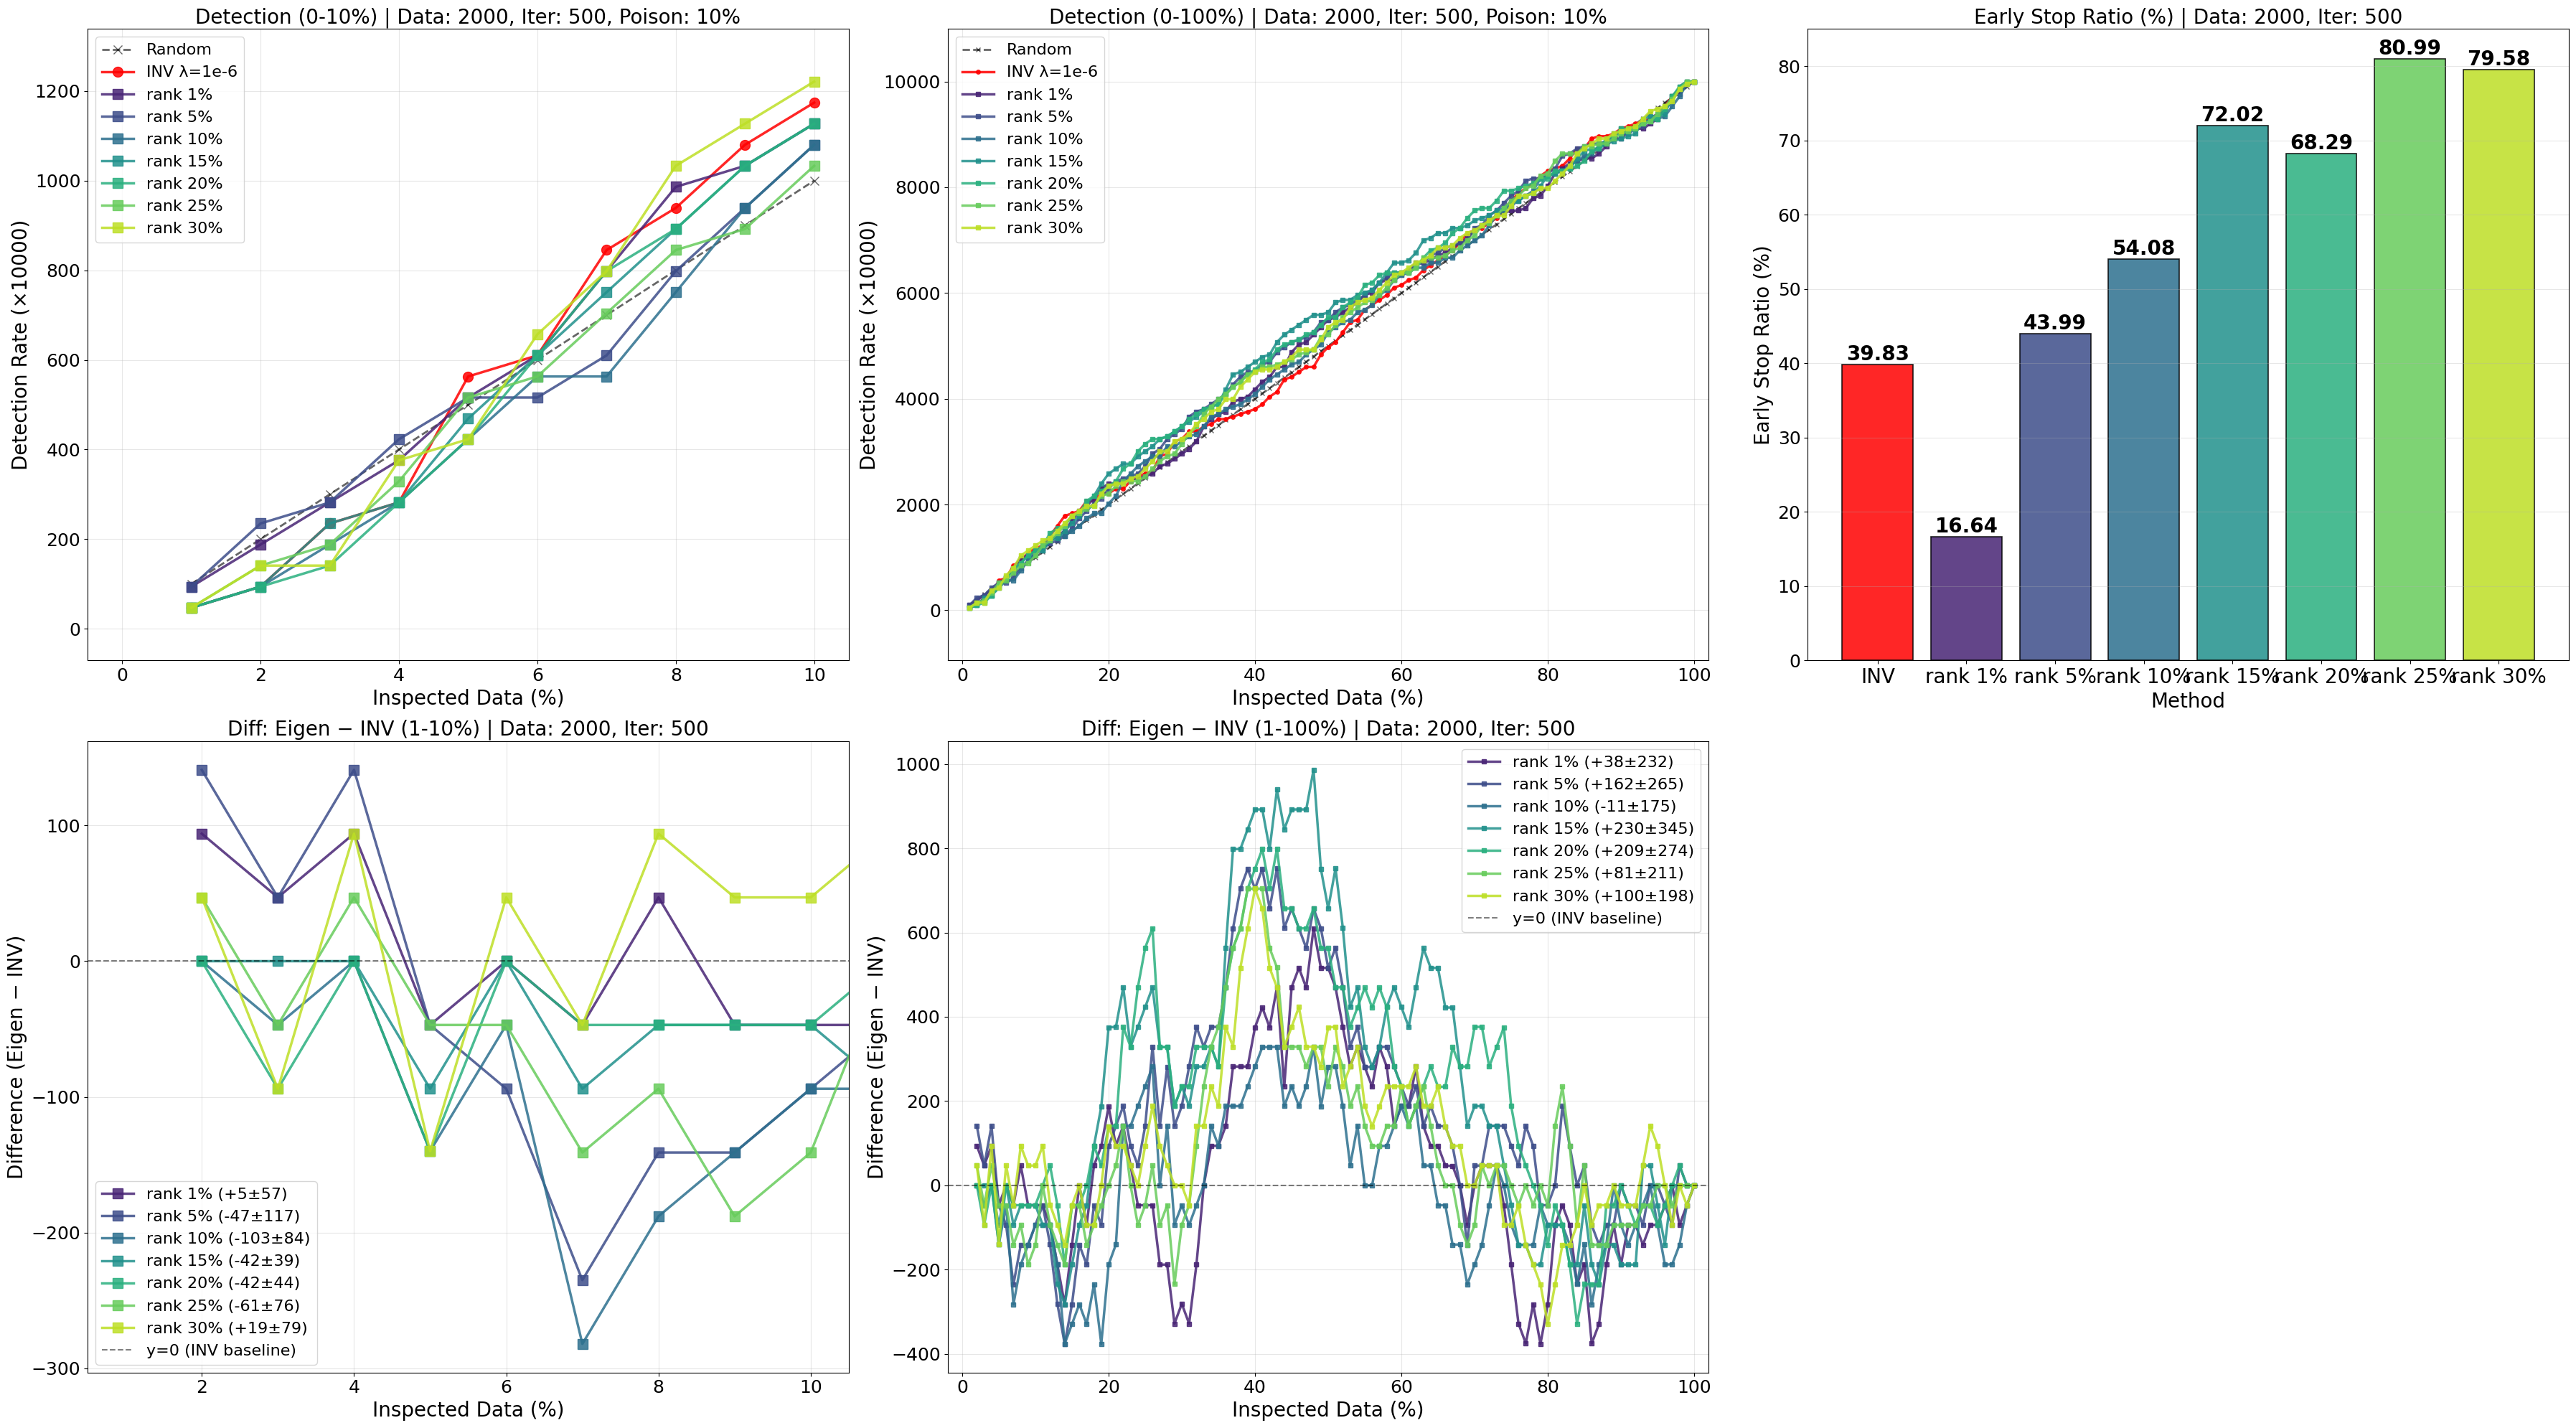

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 2000
iteration = 500
poison_pct = 10
# =========================

inspect_pct = [i for i in range(1, 101)]

# Detection rates (x10000, lowest Shapley first)
# INV baseline
inv_lam1e_6       = [47, 94, 235, 282, 563, 610, 845, 939, 1080, 1174, 1221, 1408, 1596, 1784, 1831, 1878, 2066, 2066, 2207, 2207, 2300, 2300, 2441, 2535, 2582, 2629, 2911, 2958, 3192, 3239, 3380, 3380, 3474, 3521, 3615, 3615, 3662, 3709, 3756, 3803, 3897, 4038, 4131, 4366, 4413, 4507, 4601, 4601, 4836, 4977, 5070, 5258, 5446, 5493, 5681, 5775, 5869, 5962, 6103, 6150, 6244, 6291, 6432, 6526, 6620, 6714, 6808, 6948, 7136, 7183, 7230, 7324, 7418, 7559, 7746, 7887, 7981, 8075, 8216, 8310, 8357, 8404, 8545, 8732, 8732, 8920, 8967, 8967, 9014, 9108, 9155, 9202, 9249, 9296, 9390, 9531, 9718, 9859, 10000, 10000]
# Eigen Shapley detection rates
r1_eigen_lam1e_2  = [94, 188, 282, 376, 516, 610, 798, 986, 1033, 1127, 1174, 1315, 1408, 1502, 1690, 1878, 1972, 2113, 2300, 2394, 2394, 2441, 2488, 2488, 2535, 2582, 2723, 2770, 2864, 2958, 3052, 3192, 3474, 3615, 3709, 3756, 3944, 3991, 4038, 4178, 4319, 4413, 4601, 4601, 4883, 5023, 5070, 5211, 5352, 5493, 5540, 5634, 5728, 5822, 5962, 6009, 6197, 6244, 6244, 6338, 6432, 6573, 6573, 6620, 6714, 6761, 6854, 6948, 7042, 7183, 7277, 7371, 7465, 7512, 7559, 7559, 7606, 7793, 7840, 8028, 8263, 8357, 8451, 8498, 8545, 8545, 8638, 8779, 8920, 8920, 9061, 9108, 9108, 9202, 9296, 9484, 9718, 9765, 9953, 10000]
r5_eigen_lam1e_2  = [94, 235, 282, 423, 516, 516, 610, 798, 939, 1080, 1174, 1268, 1315, 1408, 1549, 1737, 1878, 2019, 2113, 2300, 2441, 2488, 2535, 2582, 2723, 2958, 3052, 3239, 3333, 3427, 3662, 3756, 3803, 3897, 3991, 4085, 4272, 4413, 4507, 4507, 4648, 4695, 4883, 4977, 5070, 5117, 5164, 5258, 5446, 5493, 5634, 5728, 5775, 5869, 5962, 6056, 6197, 6291, 6385, 6385, 6432, 6526, 6573, 6714, 6761, 6854, 6901, 6948, 6995, 7230, 7277, 7465, 7559, 7700, 7840, 7934, 8122, 8169, 8169, 8263, 8357, 8592, 8638, 8732, 8779, 8826, 8826, 8873, 8920, 9108, 9108, 9155, 9155, 9296, 9390, 9484, 9624, 9906, 10000, 10000]
r10_eigen_lam1e_2 = [47, 94, 188, 282, 423, 563, 563, 751, 939, 1080, 1127, 1315, 1408, 1408, 1502, 1596, 1737, 1831, 1831, 2019, 2160, 2441, 2582, 2723, 2817, 2911, 2911, 3099, 3099, 3192, 3286, 3333, 3474, 3662, 3709, 3803, 3850, 3897, 3991, 4085, 4225, 4366, 4460, 4554, 4648, 4695, 4836, 4930, 5023, 5258, 5352, 5446, 5493, 5634, 5681, 5775, 5962, 6056, 6244, 6338, 6385, 6479, 6479, 6573, 6573, 6667, 6667, 6808, 6901, 6995, 7089, 7277, 7465, 7559, 7653, 7746, 7840, 7934, 8169, 8216, 8263, 8310, 8404, 8498, 8592, 8638, 8779, 8826, 9014, 9014, 9014, 9108, 9202, 9296, 9296, 9343, 9531, 9718, 9953, 10000]
r15_eigen_lam1e_2 = [47, 94, 235, 282, 469, 610, 751, 892, 1033, 1127, 1127, 1315, 1362, 1502, 1643, 1784, 2019, 2160, 2394, 2582, 2676, 2770, 2770, 2911, 3005, 3099, 3239, 3286, 3380, 3474, 3568, 3662, 3756, 3850, 3897, 4178, 4460, 4507, 4601, 4695, 4789, 4836, 5070, 5211, 5305, 5399, 5493, 5587, 5587, 5634, 5822, 5869, 5869, 5962, 6009, 6056, 6197, 6385, 6573, 6573, 6620, 6761, 6995, 7042, 7136, 7136, 7230, 7230, 7277, 7371, 7418, 7465, 7559, 7606, 7700, 7746, 7840, 7887, 8028, 8216, 8263, 8310, 8357, 8545, 8685, 8732, 8732, 8826, 8873, 8920, 8967, 9014, 9296, 9343, 9343, 9390, 9718, 9859, 10000, 10000]
r20_eigen_lam1e_2 = [47, 94, 141, 282, 423, 610, 798, 892, 1033, 1127, 1221, 1455, 1549, 1596, 1784, 1831, 2066, 2160, 2254, 2347, 2441, 2676, 2770, 3005, 3146, 3239, 3239, 3286, 3380, 3474, 3615, 3709, 3803, 3850, 3897, 4085, 4225, 4319, 4460, 4554, 4695, 4742, 4930, 5023, 5070, 5117, 5211, 5258, 5399, 5540, 5540, 5728, 5822, 5915, 6150, 6197, 6338, 6385, 6385, 6385, 6385, 6479, 6667, 6808, 6854, 6948, 7136, 7230, 7418, 7559, 7606, 7606, 7746, 7934, 7934, 7981, 8028, 8075, 8169, 8169, 8310, 8310, 8357, 8404, 8498, 8685, 8732, 8920, 8967, 9108, 9108, 9108, 9202, 9249, 9296, 9484, 9718, 9906, 10000, 10000]
r25_eigen_lam1e_2 = [47, 141, 188, 329, 516, 563, 704, 845, 892, 1033, 1221, 1315, 1455, 1596, 1784, 1831, 1925, 1972, 2160, 2207, 2347, 2441, 2441, 2441, 2535, 2676, 2817, 2911, 2958, 3146, 3333, 3474, 3709, 3850, 3991, 4085, 4225, 4319, 4460, 4507, 4601, 4601, 4648, 4695, 4742, 4836, 4883, 4930, 5164, 5211, 5399, 5540, 5634, 5728, 5822, 5869, 5962, 6103, 6244, 6385, 6385, 6479, 6667, 6667, 6667, 6714, 6808, 6854, 6995, 7089, 7277, 7324, 7465, 7606, 7746, 7840, 7981, 8028, 8216, 8263, 8498, 8638, 8638, 8638, 8779, 8779, 8826, 8826, 8920, 9014, 9061, 9108, 9202, 9249, 9390, 9531, 9671, 9859, 10000, 10000]
r30_eigen_lam1e_2 = [47, 141, 141, 376, 423, 657, 798, 1033, 1127, 1221, 1315, 1362, 1502, 1643, 1784, 1878, 1972, 1972, 2207, 2347, 2394, 2394, 2488, 2535, 2676, 2817, 3005, 3005, 3192, 3239, 3333, 3521, 3615, 3756, 3803, 3991, 3991, 4225, 4366, 4507, 4554, 4554, 4601, 4695, 4789, 4930, 4930, 4930, 5117, 5352, 5446, 5493, 5728, 5822, 5869, 5915, 6056, 6197, 6338, 6385, 6479, 6573, 6620, 6714, 6854, 6854, 6901, 7042, 7136, 7183, 7277, 7371, 7465, 7465, 7653, 7840, 7840, 7887, 7981, 7981, 8122, 8263, 8404, 8638, 8732, 8826, 8920, 8920, 9014, 9061, 9108, 9155, 9296, 9437, 9484, 9531, 9624, 9859, 9953, 10000]

# Early stop ratios (%)
inv_early_stop       = [39.83]
r1_eigen_early_stop  = [16.64]
r5_eigen_early_stop  = [43.99]
r10_eigen_early_stop = [54.08]
r15_eigen_early_stop = [72.02]
r20_eigen_early_stop = [68.29]
r25_eigen_early_stop = [80.99]
r30_eigen_early_stop = [79.58]

# Random baseline (theoretical): inspecting i% finds i% of poisoned
random_baseline = [i * 100 for i in range(1, 101)]

# Create figure with 6 subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(36, 20))
axes = axes.flatten()

# Prepare color schemes
inv_color = 'red'
random_color = 'black'
eigen_colors = plt.cm.viridis(np.linspace(0.1, 0.9, 7))

# Eigen data
eigen_data = [
    (r1_eigen_lam1e_2, 'rank 1%'),
    (r5_eigen_lam1e_2, 'rank 5%'),
    (r10_eigen_lam1e_2, 'rank 10%'),
    (r15_eigen_lam1e_2, 'rank 15%'),
    (r20_eigen_lam1e_2, 'rank 20%'),
    (r25_eigen_lam1e_2, 'rank 25%'),
    (r30_eigen_lam1e_2, 'rank 30%')
]

inspect_pct_10 = inspect_pct[:10]
inspect_pct_1_to_10 = inspect_pct[1:11]
inspect_pct_1_to_99 = inspect_pct[1:]

# ===== Subplot (1,1): Detection Rate 0-10% =====
ax1 = axes[0]

ax1.plot(inspect_pct_10, random_baseline[:10], color=random_color, linewidth=2.0,
         linestyle='--', marker='x', markersize=8, label='Random', alpha=0.6)
if inv_lam1e_6:
    ax1.plot(inspect_pct_10, inv_lam1e_6[:10], color=inv_color, linewidth=2.5,
             linestyle='-', marker='o', markersize=10, label='INV λ=1e-6', alpha=0.85)
for i, (data, label) in enumerate(eigen_data):
    if data:
        ax1.plot(inspect_pct_10, data[:10], color=eigen_colors[i], linewidth=2.5,
                 linestyle='-', marker='s', markersize=10, label=label, alpha=0.85)

all_data_10 = [random_baseline[:10]] + ([inv_lam1e_6[:10]] if inv_lam1e_6 else []) + [d[0][:10] for d in eigen_data if d[0]]
if all_data_10:
    y_min_10 = min([min(d) for d in all_data_10])
    y_max_10 = max([max(d) for d in all_data_10])
    y_margin_10 = (y_max_10 - y_min_10) * 0.1
    ax1.set_ylim(y_min_10 - y_margin_10, y_max_10 + y_margin_10)

ax1.set_xlabel('Inspected Data (%)', fontsize=20)
ax1.set_ylabel('Detection Rate (×10000)', fontsize=20)
ax1.set_title(f'Detection (0-10%) | Data: {num_dp}, Iter: {iteration}, Poison: {poison_pct}%', fontsize=20)
ax1.legend(fontsize=16, loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-0.5, 10.5)
ax1.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,2): Detection Rate 0-100% =====
ax2 = axes[1]

ax2.plot(inspect_pct, random_baseline, color=random_color, linewidth=2.0,
         linestyle='--', marker='x', markersize=4, label='Random', alpha=0.6)
if inv_lam1e_6:
    ax2.plot(inspect_pct, inv_lam1e_6, color=inv_color, linewidth=2.5,
             linestyle='-', marker='o', markersize=4, label='INV λ=1e-6', alpha=0.85)
for i, (data, label) in enumerate(eigen_data):
    if data:
        ax2.plot(inspect_pct, data, color=eigen_colors[i], linewidth=2.5,
                 linestyle='-', marker='s', markersize=4, label=label, alpha=0.85)

all_data_100 = [random_baseline] + ([inv_lam1e_6] if inv_lam1e_6 else []) + [d[0] for d in eigen_data if d[0]]
if all_data_100:
    y_min_100 = min([min(d) for d in all_data_100])
    y_max_100 = max([max(d) for d in all_data_100])
    y_margin_100 = (y_max_100 - y_min_100) * 0.1
    ax2.set_ylim(y_min_100 - y_margin_100, y_max_100 + y_margin_100)

ax2.set_xlabel('Inspected Data (%)', fontsize=20)
ax2.set_ylabel('Detection Rate (×10000)', fontsize=20)
ax2.set_title(f'Detection (0-100%) | Data: {num_dp}, Iter: {iteration}, Poison: {poison_pct}%', fontsize=20)
ax2.legend(fontsize=16, loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-2, 102)
ax2.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,3): Early Stop Ratio =====
ax3 = axes[2]

method_names = ['INV', 'rank 1%', 'rank 5%', 'rank 10%', 'rank 15%', 'rank 20%', 'rank 25%', 'rank 30%']
method_values = [
    inv_early_stop[0] if inv_early_stop else 0,
    r1_eigen_early_stop[0] if r1_eigen_early_stop else 0,
    r5_eigen_early_stop[0] if r5_eigen_early_stop else 0,
    r10_eigen_early_stop[0] if r10_eigen_early_stop else 0,
    r15_eigen_early_stop[0] if r15_eigen_early_stop else 0,
    r20_eigen_early_stop[0] if r20_eigen_early_stop else 0,
    r25_eigen_early_stop[0] if r25_eigen_early_stop else 0,
    r30_eigen_early_stop[0] if r30_eigen_early_stop else 0
]
bar_colors = [inv_color] + list(eigen_colors)

x_pos = np.arange(len(method_names))
bars = ax3.bar(x_pos, method_values, color=bar_colors, alpha=0.85, edgecolor='black', linewidth=1.2)

for bar, value in zip(bars, method_values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}', ha='center', va='bottom', fontsize=20, fontweight='bold')

ax3.set_xlabel('Method', fontsize=20)
ax3.set_ylabel('Early Stop Ratio (%)', fontsize=20)
ax3.set_title(f'Early Stop Ratio (%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(method_names, fontsize=20)
ax3.grid(True, alpha=0.3, axis='y')
ax3.tick_params(axis='y', labelsize=18)

# ===== Subplot (2,1): Difference (Eigen − INV) 1-10% =====
ax4 = axes[3]

if inv_lam1e_6:
    diff_data_10 = []
    for i, (data, label) in enumerate(eigen_data):
        if data:
            diff = np.array(data[1:11]) - np.array(inv_lam1e_6[1:11])
            diff_mean = np.mean(diff)
            diff_std = np.std(diff)
            diff_data_10.append((diff, f'{label} ({diff_mean:+.0f}±{diff_std:.0f})'))

    for i, (diff, label) in enumerate(diff_data_10):
        ax4.plot(inspect_pct_1_to_10, diff, color=eigen_colors[i], linewidth=2.5,
                 linestyle='-', marker='s', markersize=10, label=label, alpha=0.85)

ax4.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=0 (INV baseline)')

ax4.set_xlabel('Inspected Data (%)', fontsize=20)
ax4.set_ylabel('Difference (Eigen − INV)', fontsize=20)
ax4.set_title(f'Diff: Eigen − INV (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax4.legend(fontsize=16, loc='best')
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0.5, 10.5)
ax4.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,2): Difference (Eigen − INV) 1-100% =====
ax5 = axes[4]

if inv_lam1e_6:
    diff_data_100 = []
    for i, (data, label) in enumerate(eigen_data):
        if data:
            diff = np.array(data[1:]) - np.array(inv_lam1e_6[1:])
            diff_mean = np.mean(diff)
            diff_std = np.std(diff)
            diff_data_100.append((diff, f'{label} ({diff_mean:+.0f}±{diff_std:.0f})'))

    for i, (diff, label) in enumerate(diff_data_100):
        ax5.plot(inspect_pct_1_to_99, diff, color=eigen_colors[i], linewidth=2.5,
                 linestyle='-', marker='s', markersize=4, label=label, alpha=0.85)

ax5.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=0 (INV baseline)')

ax5.set_xlabel('Inspected Data (%)', fontsize=20)
ax5.set_ylabel('Difference (Eigen − INV)', fontsize=20)
ax5.set_title(f'Diff: Eigen − INV (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax5.legend(fontsize=16, loc='best')
ax5.grid(True, alpha=0.3)
ax5.set_xlim(-2, 102)
ax5.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,3): Turn off unused subplot =====
axes[5].axis('off')

plt.tight_layout()
plt.savefig(f'wld_seed2025_iter{iteration}_num{num_dp}.png', dpi=100, bbox_inches='tight')
plt.show()

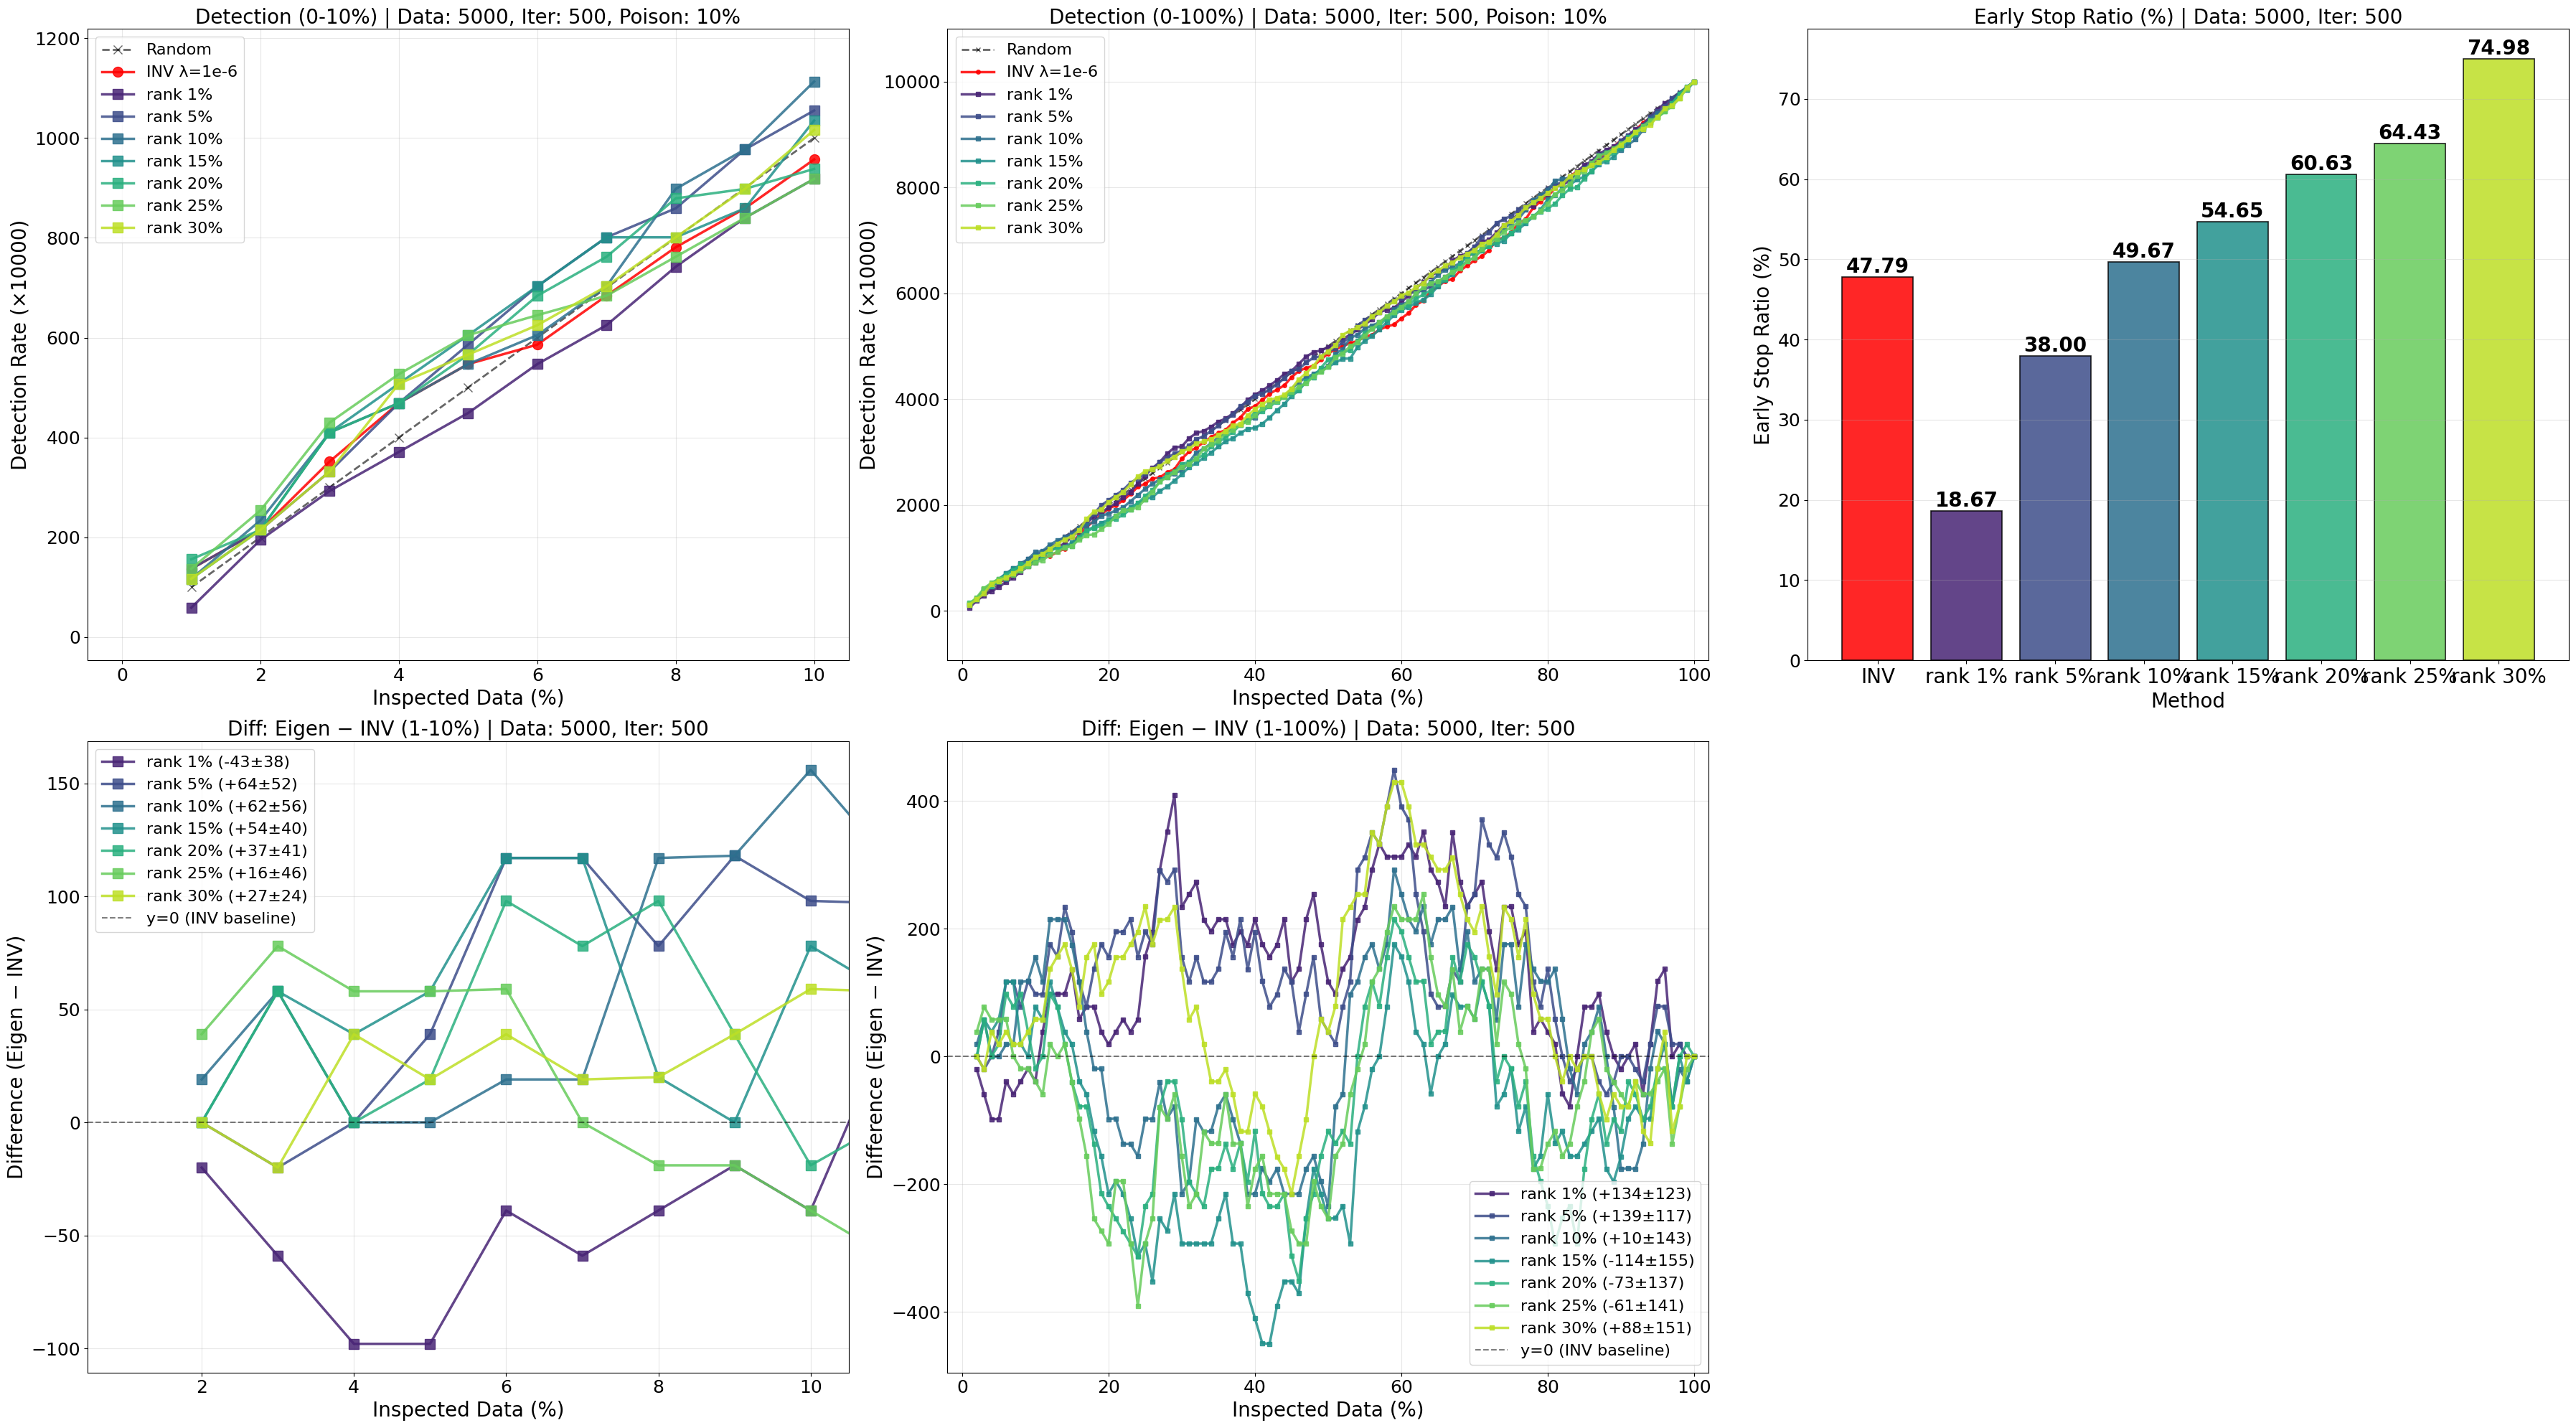

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 5000
iteration = 500
poison_pct = 10
# =========================

inspect_pct = [i for i in range(1, 101)]

# Detection rates (x10000, lowest Shapley first)
# INV baseline
inv_lam1e_6       = [137, 215, 352, 469, 547, 586, 684, 781, 859, 957, 1016, 1035, 1113, 1172, 1270, 1445, 1582, 1699, 1816, 1934, 1992, 2090, 2207, 2344, 2402, 2500, 2520, 2617, 2676, 2871, 3008, 3086, 3184, 3281, 3359, 3418, 3555, 3652, 3809, 3867, 3984, 4102, 4180, 4258, 4414, 4531, 4590, 4629, 4746, 4863, 4941, 5000, 5059, 5098, 5176, 5215, 5312, 5371, 5410, 5527, 5625, 5781, 5859, 6035, 6133, 6230, 6270, 6426, 6523, 6621, 6699, 6816, 7012, 7051, 7148, 7324, 7402, 7617, 7734, 7832, 7988, 8105, 8203, 8301, 8340, 8418, 8535, 8672, 8770, 8887, 8984, 9082, 9219, 9316, 9355, 9453, 9668, 9766, 9883, 10000]
# Eigen Shapley detection rates
r1_eigen_lam1e_2  = [59, 195, 293, 371, 449, 547, 625, 742, 840, 918, 1055, 1133, 1211, 1270, 1406, 1504, 1660, 1777, 1855, 1953, 2031, 2148, 2246, 2402, 2559, 2695, 2812, 2969, 3086, 3105, 3262, 3359, 3398, 3477, 3574, 3633, 3730, 3848, 3984, 4082, 4160, 4258, 4355, 4473, 4531, 4668, 4805, 4883, 4922, 4980, 5039, 5137, 5215, 5312, 5410, 5508, 5645, 5684, 5723, 5840, 5957, 6094, 6211, 6328, 6406, 6465, 6621, 6699, 6758, 6875, 6973, 7012, 7148, 7285, 7383, 7500, 7598, 7656, 7793, 7871, 8008, 8047, 8125, 8301, 8418, 8496, 8633, 8711, 8770, 8867, 8984, 9102, 9160, 9336, 9473, 9590, 9668, 9785, 9883, 10000]
r5_eigen_lam1e_2  = [137, 215, 332, 469, 586, 703, 801, 859, 977, 1055, 1113, 1211, 1270, 1406, 1465, 1562, 1660, 1836, 1992, 2090, 2188, 2285, 2422, 2500, 2598, 2676, 2812, 2891, 2969, 3027, 3125, 3242, 3301, 3398, 3496, 3613, 3711, 3867, 3945, 4062, 4102, 4180, 4277, 4395, 4531, 4570, 4688, 4785, 4805, 4902, 4961, 5078, 5176, 5391, 5488, 5566, 5645, 5762, 5859, 5918, 5996, 6035, 6055, 6133, 6211, 6309, 6406, 6543, 6758, 6875, 7070, 7148, 7324, 7402, 7461, 7578, 7637, 7734, 7812, 7969, 8047, 8105, 8164, 8281, 8340, 8418, 8496, 8613, 8730, 8887, 8984, 9062, 9180, 9336, 9434, 9531, 9688, 9785, 9883, 10000]
r10_eigen_lam1e_2 = [117, 234, 410, 469, 547, 605, 703, 898, 977, 1113, 1133, 1250, 1328, 1387, 1445, 1562, 1621, 1680, 1797, 1836, 1895, 1953, 2070, 2188, 2305, 2402, 2480, 2520, 2598, 2656, 2812, 2988, 3066, 3164, 3281, 3359, 3457, 3516, 3594, 3652, 3809, 3906, 4004, 4043, 4199, 4316, 4414, 4473, 4551, 4629, 4863, 4941, 5156, 5215, 5332, 5391, 5449, 5547, 5703, 5781, 5840, 5977, 6094, 6211, 6348, 6445, 6504, 6562, 6719, 6738, 6836, 6953, 7070, 7227, 7324, 7402, 7578, 7754, 7852, 7949, 8125, 8164, 8184, 8242, 8359, 8457, 8613, 8672, 8691, 8711, 8809, 8906, 9082, 9297, 9395, 9473, 9590, 9746, 9844, 10000]
r15_eigen_lam1e_2 = [117, 215, 410, 508, 605, 703, 801, 801, 859, 1035, 1074, 1152, 1191, 1211, 1289, 1406, 1523, 1582, 1660, 1719, 1797, 1875, 1953, 2031, 2109, 2148, 2266, 2344, 2461, 2578, 2715, 2793, 2891, 2988, 3105, 3203, 3262, 3359, 3438, 3457, 3535, 3652, 3789, 3906, 4062, 4160, 4336, 4453, 4531, 4609, 4688, 4766, 4766, 4980, 5098, 5195, 5312, 5449, 5586, 5684, 5742, 5820, 5879, 5977, 6133, 6250, 6367, 6504, 6602, 6680, 6816, 6895, 6934, 6992, 7129, 7207, 7324, 7441, 7578, 7773, 7852, 7988, 8047, 8145, 8203, 8301, 8438, 8496, 8574, 8730, 8887, 9004, 9121, 9219, 9336, 9473, 9590, 9766, 9844, 10000]
r20_eigen_lam1e_2 = [156, 215, 410, 469, 566, 684, 762, 879, 898, 938, 1016, 1133, 1191, 1191, 1230, 1367, 1504, 1562, 1602, 1699, 1738, 1816, 1914, 2031, 2168, 2285, 2441, 2578, 2637, 2773, 2812, 2871, 2949, 3105, 3184, 3281, 3379, 3516, 3613, 3750, 3770, 3867, 3945, 4043, 4102, 4180, 4336, 4414, 4590, 4746, 4805, 4883, 4922, 5098, 5254, 5332, 5391, 5527, 5625, 5723, 5781, 5898, 5977, 6055, 6172, 6270, 6426, 6543, 6699, 6777, 6816, 6895, 6973, 7051, 7129, 7246, 7363, 7461, 7539, 7598, 7695, 7852, 7969, 8008, 8164, 8320, 8477, 8535, 8672, 8770, 8945, 9023, 9121, 9238, 9336, 9434, 9590, 9766, 9902, 10000]
r25_eigen_lam1e_2 = [137, 254, 430, 527, 605, 645, 684, 762, 840, 918, 957, 1055, 1113, 1191, 1230, 1348, 1426, 1445, 1543, 1641, 1797, 1895, 1914, 1953, 2109, 2246, 2441, 2520, 2617, 2715, 2773, 2871, 3066, 3145, 3223, 3359, 3418, 3516, 3574, 3691, 3828, 3887, 3965, 4043, 4141, 4238, 4297, 4434, 4512, 4609, 4785, 4863, 5000, 5078, 5195, 5332, 5449, 5566, 5645, 5742, 5840, 5996, 6113, 6191, 6230, 6309, 6406, 6465, 6602, 6680, 6836, 6953, 7031, 7168, 7246, 7344, 7383, 7441, 7559, 7695, 7871, 7949, 8066, 8223, 8301, 8457, 8594, 8652, 8730, 8828, 8906, 9043, 9160, 9258, 9316, 9434, 9531, 9688, 9863, 10000]
r30_eigen_lam1e_2 = [117, 215, 332, 508, 566, 625, 703, 801, 898, 1016, 1074, 1172, 1270, 1348, 1406, 1523, 1738, 1875, 1914, 2051, 2148, 2246, 2383, 2539, 2637, 2676, 2734, 2832, 2910, 3008, 3066, 3164, 3203, 3242, 3320, 3398, 3496, 3535, 3691, 3809, 3906, 3984, 4023, 4082, 4199, 4375, 4492, 4629, 4805, 4902, 5020, 5215, 5293, 5352, 5430, 5566, 5645, 5762, 5840, 5957, 6016, 6113, 6191, 6348, 6426, 6523, 6582, 6680, 6738, 6816, 6934, 6973, 7109, 7285, 7363, 7480, 7617, 7715, 7793, 7891, 7988, 8066, 8203, 8281, 8340, 8418, 8477, 8574, 8711, 8809, 8906, 9043, 9102, 9180, 9336, 9492, 9551, 9688, 9883, 10000]

# Early stop ratios (%)
inv_early_stop       = [47.79]
r1_eigen_early_stop  = [18.67]
r5_eigen_early_stop  = [38.00]
r10_eigen_early_stop = [49.67]
r15_eigen_early_stop = [54.65]
r20_eigen_early_stop = [60.63]
r25_eigen_early_stop = [64.43]
r30_eigen_early_stop = [74.98]

# Random baseline (theoretical): inspecting i% finds i% of poisoned
random_baseline = [i * 100 for i in range(1, 101)]

# Create figure with 6 subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(36, 20))
axes = axes.flatten()

# Prepare color schemes
inv_color = 'red'
random_color = 'black'
eigen_colors = plt.cm.viridis(np.linspace(0.1, 0.9, 7))

# Eigen data
eigen_data = [
    (r1_eigen_lam1e_2, 'rank 1%'),
    (r5_eigen_lam1e_2, 'rank 5%'),
    (r10_eigen_lam1e_2, 'rank 10%'),
    (r15_eigen_lam1e_2, 'rank 15%'),
    (r20_eigen_lam1e_2, 'rank 20%'),
    (r25_eigen_lam1e_2, 'rank 25%'),
    (r30_eigen_lam1e_2, 'rank 30%')
]

inspect_pct_10 = inspect_pct[:10]
inspect_pct_1_to_10 = inspect_pct[1:11]
inspect_pct_1_to_99 = inspect_pct[1:]

# ===== Subplot (1,1): Detection Rate 0-10% =====
ax1 = axes[0]

ax1.plot(inspect_pct_10, random_baseline[:10], color=random_color, linewidth=2.0,
         linestyle='--', marker='x', markersize=8, label='Random', alpha=0.6)
if inv_lam1e_6:
    ax1.plot(inspect_pct_10, inv_lam1e_6[:10], color=inv_color, linewidth=2.5,
             linestyle='-', marker='o', markersize=10, label='INV λ=1e-6', alpha=0.85)
for i, (data, label) in enumerate(eigen_data):
    if data:
        ax1.plot(inspect_pct_10, data[:10], color=eigen_colors[i], linewidth=2.5,
                 linestyle='-', marker='s', markersize=10, label=label, alpha=0.85)

all_data_10 = [random_baseline[:10]] + ([inv_lam1e_6[:10]] if inv_lam1e_6 else []) + [d[0][:10] for d in eigen_data if d[0]]
if all_data_10:
    y_min_10 = min([min(d) for d in all_data_10])
    y_max_10 = max([max(d) for d in all_data_10])
    y_margin_10 = (y_max_10 - y_min_10) * 0.1
    ax1.set_ylim(y_min_10 - y_margin_10, y_max_10 + y_margin_10)

ax1.set_xlabel('Inspected Data (%)', fontsize=20)
ax1.set_ylabel('Detection Rate (×10000)', fontsize=20)
ax1.set_title(f'Detection (0-10%) | Data: {num_dp}, Iter: {iteration}, Poison: {poison_pct}%', fontsize=20)
ax1.legend(fontsize=16, loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-0.5, 10.5)
ax1.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,2): Detection Rate 0-100% =====
ax2 = axes[1]

ax2.plot(inspect_pct, random_baseline, color=random_color, linewidth=2.0,
         linestyle='--', marker='x', markersize=4, label='Random', alpha=0.6)
if inv_lam1e_6:
    ax2.plot(inspect_pct, inv_lam1e_6, color=inv_color, linewidth=2.5,
             linestyle='-', marker='o', markersize=4, label='INV λ=1e-6', alpha=0.85)
for i, (data, label) in enumerate(eigen_data):
    if data:
        ax2.plot(inspect_pct, data, color=eigen_colors[i], linewidth=2.5,
                 linestyle='-', marker='s', markersize=4, label=label, alpha=0.85)

all_data_100 = [random_baseline] + ([inv_lam1e_6] if inv_lam1e_6 else []) + [d[0] for d in eigen_data if d[0]]
if all_data_100:
    y_min_100 = min([min(d) for d in all_data_100])
    y_max_100 = max([max(d) for d in all_data_100])
    y_margin_100 = (y_max_100 - y_min_100) * 0.1
    ax2.set_ylim(y_min_100 - y_margin_100, y_max_100 + y_margin_100)

ax2.set_xlabel('Inspected Data (%)', fontsize=20)
ax2.set_ylabel('Detection Rate (×10000)', fontsize=20)
ax2.set_title(f'Detection (0-100%) | Data: {num_dp}, Iter: {iteration}, Poison: {poison_pct}%', fontsize=20)
ax2.legend(fontsize=16, loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-2, 102)
ax2.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,3): Early Stop Ratio =====
ax3 = axes[2]

method_names = ['INV', 'rank 1%', 'rank 5%', 'rank 10%', 'rank 15%', 'rank 20%', 'rank 25%', 'rank 30%']
method_values = [
    inv_early_stop[0] if inv_early_stop else 0,
    r1_eigen_early_stop[0] if r1_eigen_early_stop else 0,
    r5_eigen_early_stop[0] if r5_eigen_early_stop else 0,
    r10_eigen_early_stop[0] if r10_eigen_early_stop else 0,
    r15_eigen_early_stop[0] if r15_eigen_early_stop else 0,
    r20_eigen_early_stop[0] if r20_eigen_early_stop else 0,
    r25_eigen_early_stop[0] if r25_eigen_early_stop else 0,
    r30_eigen_early_stop[0] if r30_eigen_early_stop else 0
]
bar_colors = [inv_color] + list(eigen_colors)

x_pos = np.arange(len(method_names))
bars = ax3.bar(x_pos, method_values, color=bar_colors, alpha=0.85, edgecolor='black', linewidth=1.2)

for bar, value in zip(bars, method_values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}', ha='center', va='bottom', fontsize=20, fontweight='bold')

ax3.set_xlabel('Method', fontsize=20)
ax3.set_ylabel('Early Stop Ratio (%)', fontsize=20)
ax3.set_title(f'Early Stop Ratio (%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(method_names, fontsize=20)
ax3.grid(True, alpha=0.3, axis='y')
ax3.tick_params(axis='y', labelsize=18)

# ===== Subplot (2,1): Difference (Eigen − INV) 1-10% =====
ax4 = axes[3]

if inv_lam1e_6:
    diff_data_10 = []
    for i, (data, label) in enumerate(eigen_data):
        if data:
            diff = np.array(data[1:11]) - np.array(inv_lam1e_6[1:11])
            diff_mean = np.mean(diff)
            diff_std = np.std(diff)
            diff_data_10.append((diff, f'{label} ({diff_mean:+.0f}±{diff_std:.0f})'))

    for i, (diff, label) in enumerate(diff_data_10):
        ax4.plot(inspect_pct_1_to_10, diff, color=eigen_colors[i], linewidth=2.5,
                 linestyle='-', marker='s', markersize=10, label=label, alpha=0.85)

ax4.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=0 (INV baseline)')

ax4.set_xlabel('Inspected Data (%)', fontsize=20)
ax4.set_ylabel('Difference (Eigen − INV)', fontsize=20)
ax4.set_title(f'Diff: Eigen − INV (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax4.legend(fontsize=16, loc='best')
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0.5, 10.5)
ax4.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,2): Difference (Eigen − INV) 1-100% =====
ax5 = axes[4]

if inv_lam1e_6:
    diff_data_100 = []
    for i, (data, label) in enumerate(eigen_data):
        if data:
            diff = np.array(data[1:]) - np.array(inv_lam1e_6[1:])
            diff_mean = np.mean(diff)
            diff_std = np.std(diff)
            diff_data_100.append((diff, f'{label} ({diff_mean:+.0f}±{diff_std:.0f})'))

    for i, (diff, label) in enumerate(diff_data_100):
        ax5.plot(inspect_pct_1_to_99, diff, color=eigen_colors[i], linewidth=2.5,
                 linestyle='-', marker='s', markersize=4, label=label, alpha=0.85)

ax5.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=0 (INV baseline)')

ax5.set_xlabel('Inspected Data (%)', fontsize=20)
ax5.set_ylabel('Difference (Eigen − INV)', fontsize=20)
ax5.set_title(f'Diff: Eigen − INV (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax5.legend(fontsize=16, loc='best')
ax5.grid(True, alpha=0.3)
ax5.set_xlim(-2, 102)
ax5.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,3): Turn off unused subplot =====
axes[5].axis('off')

plt.tight_layout()
plt.savefig(f'wld_seed2025_iter{iteration}_num{num_dp}.png', dpi=100, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 10000
iteration = 500
poison_pct = 10
# =========================

inspect_pct = [i for i in range(1, 101)]

# Detection rates (x10000, lowest Shapley first)
# INV baseline
inv_lam1e_6       = []
# Eigen Shapley detection rates
r1_eigen_lam1e_2  = []
r5_eigen_lam1e_2  = []
r10_eigen_lam1e_2 = []
r15_eigen_lam1e_2 = []
r20_eigen_lam1e_2 = []
r25_eigen_lam1e_2 = []
r30_eigen_lam1e_2 = []

# Early stop ratios (%)
inv_early_stop       = []
r1_eigen_early_stop  = []
r5_eigen_early_stop  = []
r10_eigen_early_stop = []
r15_eigen_early_stop = []
r20_eigen_early_stop = []
r25_eigen_early_stop = []
r30_eigen_early_stop = []

# Random baseline (theoretical): inspecting i% finds i% of poisoned
random_baseline = [i * 100 for i in range(1, 101)]

# Create figure with 6 subplots (2 rows, 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(36, 20))
axes = axes.flatten()

# Prepare color schemes
inv_color = 'red'
random_color = 'black'
eigen_colors = plt.cm.viridis(np.linspace(0.1, 0.9, 7))

# Eigen data
eigen_data = [
    (r1_eigen_lam1e_2, 'rank 1%'),
    (r5_eigen_lam1e_2, 'rank 5%'),
    (r10_eigen_lam1e_2, 'rank 10%'),
    (r15_eigen_lam1e_2, 'rank 15%'),
    (r20_eigen_lam1e_2, 'rank 20%'),
    (r25_eigen_lam1e_2, 'rank 25%'),
    (r30_eigen_lam1e_2, 'rank 30%')
]

inspect_pct_10 = inspect_pct[:10]
inspect_pct_1_to_10 = inspect_pct[1:11]
inspect_pct_1_to_99 = inspect_pct[1:]

# ===== Subplot (1,1): Detection Rate 0-10% =====
ax1 = axes[0]

ax1.plot(inspect_pct_10, random_baseline[:10], color=random_color, linewidth=2.0,
         linestyle='--', marker='x', markersize=8, label='Random', alpha=0.6)
if inv_lam1e_6:
    ax1.plot(inspect_pct_10, inv_lam1e_6[:10], color=inv_color, linewidth=2.5,
             linestyle='-', marker='o', markersize=10, label='INV λ=1e-6', alpha=0.85)
for i, (data, label) in enumerate(eigen_data):
    if data:
        ax1.plot(inspect_pct_10, data[:10], color=eigen_colors[i], linewidth=2.5,
                 linestyle='-', marker='s', markersize=10, label=label, alpha=0.85)

all_data_10 = [random_baseline[:10]] + ([inv_lam1e_6[:10]] if inv_lam1e_6 else []) + [d[0][:10] for d in eigen_data if d[0]]
if all_data_10:
    y_min_10 = min([min(d) for d in all_data_10])
    y_max_10 = max([max(d) for d in all_data_10])
    y_margin_10 = (y_max_10 - y_min_10) * 0.1
    ax1.set_ylim(y_min_10 - y_margin_10, y_max_10 + y_margin_10)

ax1.set_xlabel('Inspected Data (%)', fontsize=20)
ax1.set_ylabel('Detection Rate (×10000)', fontsize=20)
ax1.set_title(f'Detection (0-10%) | Data: {num_dp}, Iter: {iteration}, Poison: {poison_pct}%', fontsize=20)
ax1.legend(fontsize=16, loc='best')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-0.5, 10.5)
ax1.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,2): Detection Rate 0-100% =====
ax2 = axes[1]

ax2.plot(inspect_pct, random_baseline, color=random_color, linewidth=2.0,
         linestyle='--', marker='x', markersize=4, label='Random', alpha=0.6)
if inv_lam1e_6:
    ax2.plot(inspect_pct, inv_lam1e_6, color=inv_color, linewidth=2.5,
             linestyle='-', marker='o', markersize=4, label='INV λ=1e-6', alpha=0.85)
for i, (data, label) in enumerate(eigen_data):
    if data:
        ax2.plot(inspect_pct, data, color=eigen_colors[i], linewidth=2.5,
                 linestyle='-', marker='s', markersize=4, label=label, alpha=0.85)

all_data_100 = [random_baseline] + ([inv_lam1e_6] if inv_lam1e_6 else []) + [d[0] for d in eigen_data if d[0]]
if all_data_100:
    y_min_100 = min([min(d) for d in all_data_100])
    y_max_100 = max([max(d) for d in all_data_100])
    y_margin_100 = (y_max_100 - y_min_100) * 0.1
    ax2.set_ylim(y_min_100 - y_margin_100, y_max_100 + y_margin_100)

ax2.set_xlabel('Inspected Data (%)', fontsize=20)
ax2.set_ylabel('Detection Rate (×10000)', fontsize=20)
ax2.set_title(f'Detection (0-100%) | Data: {num_dp}, Iter: {iteration}, Poison: {poison_pct}%', fontsize=20)
ax2.legend(fontsize=16, loc='best')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-2, 102)
ax2.tick_params(axis='both', labelsize=18)

# ===== Subplot (1,3): Early Stop Ratio =====
ax3 = axes[2]

method_names = ['INV', 'rank 1%', 'rank 5%', 'rank 10%', 'rank 15%', 'rank 20%', 'rank 25%', 'rank 30%']
method_values = [
    inv_early_stop[0] if inv_early_stop else 0,
    r1_eigen_early_stop[0] if r1_eigen_early_stop else 0,
    r5_eigen_early_stop[0] if r5_eigen_early_stop else 0,
    r10_eigen_early_stop[0] if r10_eigen_early_stop else 0,
    r15_eigen_early_stop[0] if r15_eigen_early_stop else 0,
    r20_eigen_early_stop[0] if r20_eigen_early_stop else 0,
    r25_eigen_early_stop[0] if r25_eigen_early_stop else 0,
    r30_eigen_early_stop[0] if r30_eigen_early_stop else 0
]
bar_colors = [inv_color] + list(eigen_colors)

x_pos = np.arange(len(method_names))
bars = ax3.bar(x_pos, method_values, color=bar_colors, alpha=0.85, edgecolor='black', linewidth=1.2)

for bar, value in zip(bars, method_values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
             f'{value:.2f}', ha='center', va='bottom', fontsize=20, fontweight='bold')

ax3.set_xlabel('Method', fontsize=20)
ax3.set_ylabel('Early Stop Ratio (%)', fontsize=20)
ax3.set_title(f'Early Stop Ratio (%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax3.set_xticks(x_pos)
ax3.set_xticklabels(method_names, fontsize=20)
ax3.grid(True, alpha=0.3, axis='y')
ax3.tick_params(axis='y', labelsize=18)

# ===== Subplot (2,1): Difference (Eigen − INV) 1-10% =====
ax4 = axes[3]

if inv_lam1e_6:
    diff_data_10 = []
    for i, (data, label) in enumerate(eigen_data):
        if data:
            diff = np.array(data[1:11]) - np.array(inv_lam1e_6[1:11])
            diff_mean = np.mean(diff)
            diff_std = np.std(diff)
            diff_data_10.append((diff, f'{label} ({diff_mean:+.0f}±{diff_std:.0f})'))

    for i, (diff, label) in enumerate(diff_data_10):
        ax4.plot(inspect_pct_1_to_10, diff, color=eigen_colors[i], linewidth=2.5,
                 linestyle='-', marker='s', markersize=10, label=label, alpha=0.85)

ax4.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=0 (INV baseline)')

ax4.set_xlabel('Inspected Data (%)', fontsize=20)
ax4.set_ylabel('Difference (Eigen − INV)', fontsize=20)
ax4.set_title(f'Diff: Eigen − INV (1-10%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax4.legend(fontsize=16, loc='best')
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0.5, 10.5)
ax4.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,2): Difference (Eigen − INV) 1-100% =====
ax5 = axes[4]

if inv_lam1e_6:
    diff_data_100 = []
    for i, (data, label) in enumerate(eigen_data):
        if data:
            diff = np.array(data[1:]) - np.array(inv_lam1e_6[1:])
            diff_mean = np.mean(diff)
            diff_std = np.std(diff)
            diff_data_100.append((diff, f'{label} ({diff_mean:+.0f}±{diff_std:.0f})'))

    for i, (diff, label) in enumerate(diff_data_100):
        ax5.plot(inspect_pct_1_to_99, diff, color=eigen_colors[i], linewidth=2.5,
                 linestyle='-', marker='s', markersize=4, label=label, alpha=0.85)

ax5.axhline(y=0, color='black', linestyle='--', linewidth=1.5, alpha=0.5, label='y=0 (INV baseline)')

ax5.set_xlabel('Inspected Data (%)', fontsize=20)
ax5.set_ylabel('Difference (Eigen − INV)', fontsize=20)
ax5.set_title(f'Diff: Eigen − INV (1-100%) | Data: {num_dp}, Iter: {iteration}', fontsize=20)
ax5.legend(fontsize=16, loc='best')
ax5.grid(True, alpha=0.3)
ax5.set_xlim(-2, 102)
ax5.tick_params(axis='both', labelsize=18)

# ===== Subplot (2,3): Turn off unused subplot =====
axes[5].axis('off')

plt.tight_layout()
plt.savefig(f'wld_seed2025_iter{iteration}_num{num_dp}.png', dpi=100, bbox_inches='tight')
plt.show()